In [141]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import os

In [142]:
import sys
import importlib

# --- FIX: AUTORELOAD FOR JUPYTER ---
# These lines ensure that when you save changes to logistic_regression.py, 
# the notebook will automatically reload the new code.
%load_ext autoreload
%autoreload 2
# -----------------------------------

proc_lib='processing_utils'

# Now importing DH_OBJ from the logistic_regression package
try:
    # 1. Check if the module is already loaded (cached)
    if proc_lib in sys.modules:
        print(f"Module {proc_lib} found in cache. Forcing reload...")
        importlib.reload(sys.modules['processing_utils'])
    
    # 2. Perform the import (this will use the reloaded or new version)
    import processing_utils as proc
except ImportError as e:
    print(f"\n[ERROR] Import failed. Ensure your {proc_lib} file are correctly structured.")
    print(f"Details: {e}")
    sys.exit(1)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Module processing_utils found in cache. Forcing reload...


# 0. Inputs

In [143]:
# Arguments. Test purpose only
input_dir = "/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-21-14-25-34"
test_type = "default"
# loads_type = ["idle", "load-net", "load-usb", "load-net-usb"]
loads_type = ["idle", "load-net"]
channels = [0, 1]
nominal_period_us = 200000
duration_s = 10

# Create array of data to use in the loop
plots = []
plotsLoad = []
for load_type in loads_type:
    plot = proc.Plot_obj(input_dir, test_type, load_type, channels, nominal_period_us, duration_s)
    plots.append(plot)

# Load and process data
for plot in plots:
    plot.load_and_process_datas()

Successfully matched graph channel 0 to column 'Channel 0'
Successfully matched graph channel 1 to column 'Channel 1'
Successfully matched graph channel 0 to column 'Channel 0'
Successfully matched graph channel 1 to column 'Channel 1'


# 1. Jitter plus

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-21-14-25-34/jitter_histogram_default_idle_rise.png'


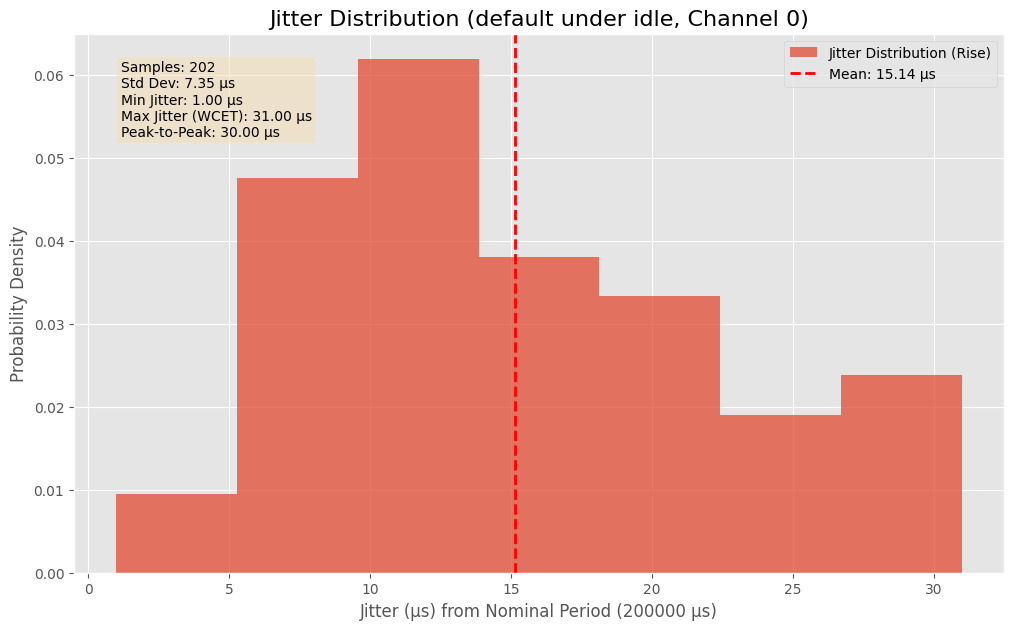

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-21-14-25-34/jitter_histogram_default_idle_fall.png'


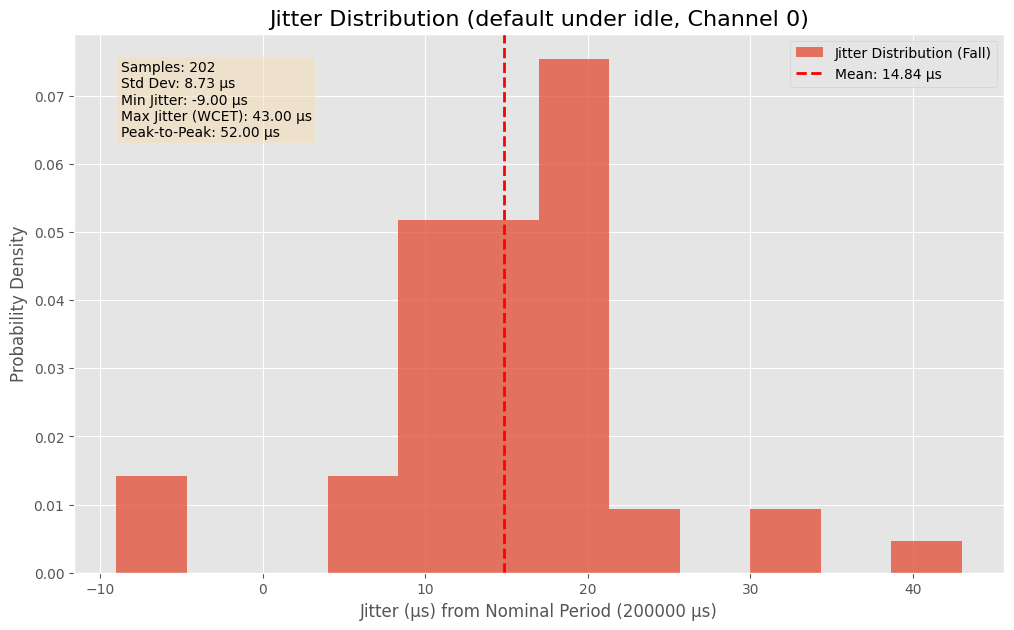

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-21-14-25-34/jitter_histogram_default_idle_rise_fall.png'


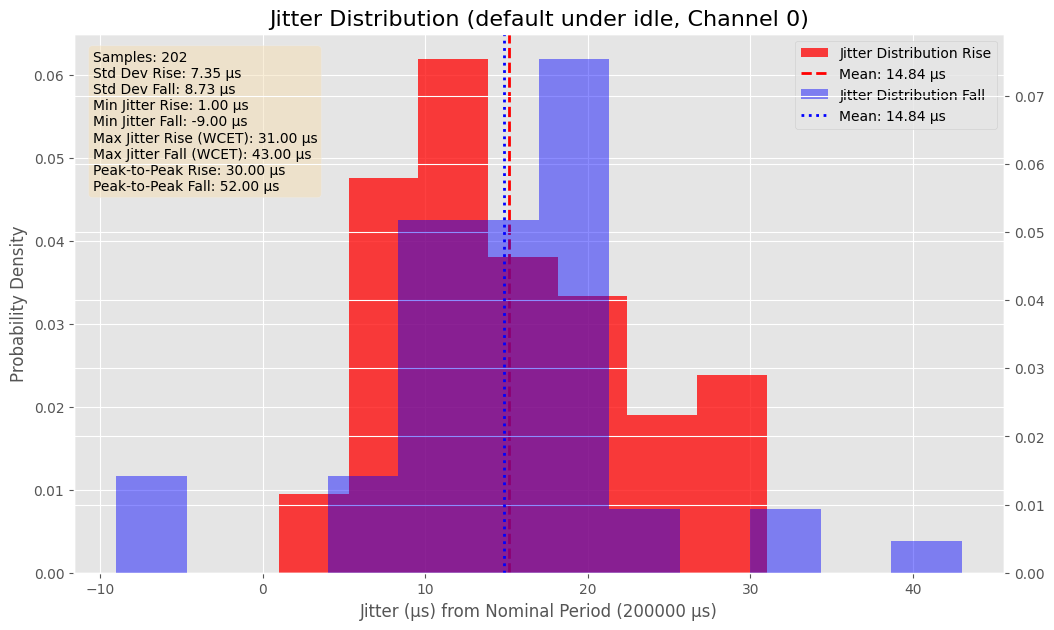

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-21-14-25-34/jitter_histogram_default_idle_rise.png'


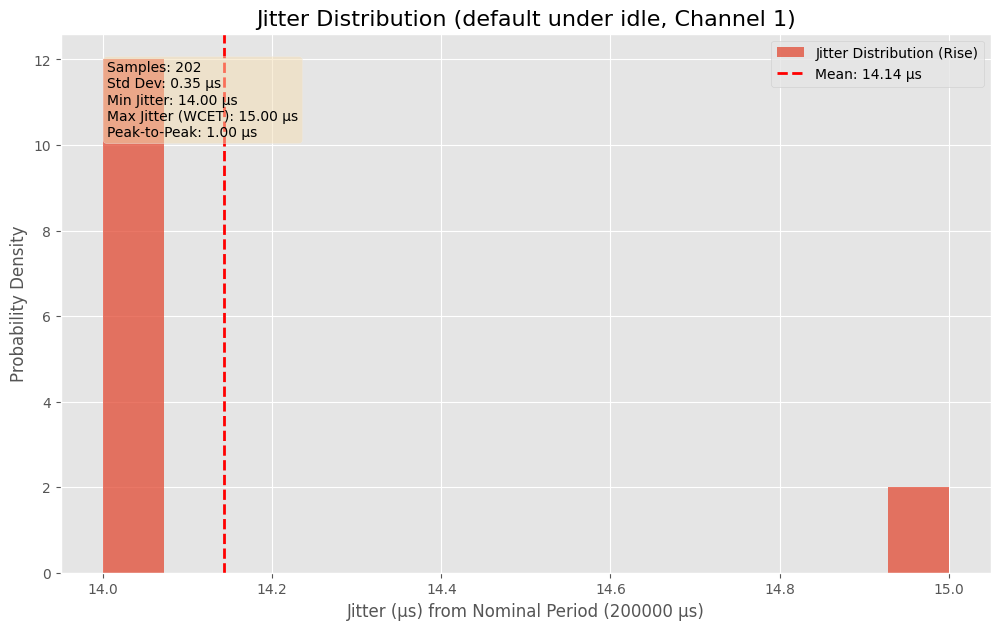

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-21-14-25-34/jitter_histogram_default_idle_fall.png'


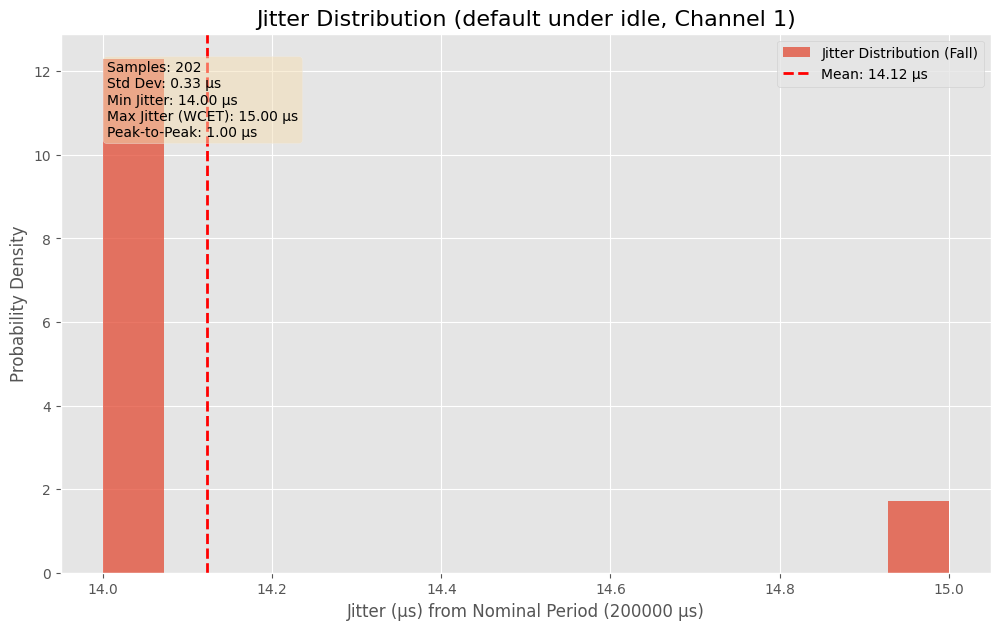

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-21-14-25-34/jitter_histogram_default_idle_rise_fall.png'


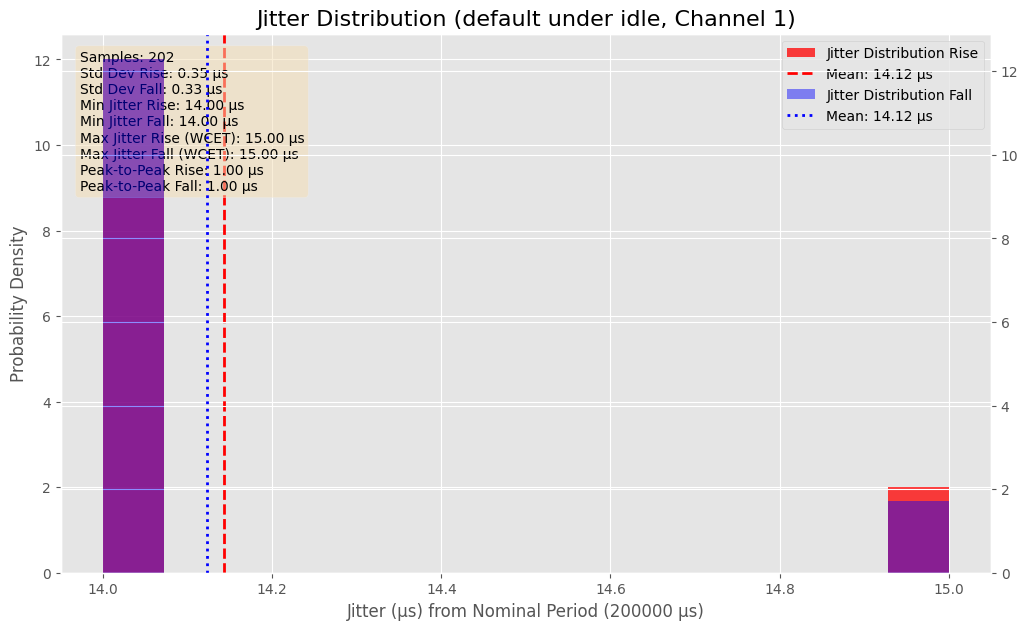

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-21-14-25-34/jitter_histogram_default_idle_cyclic_test.png'


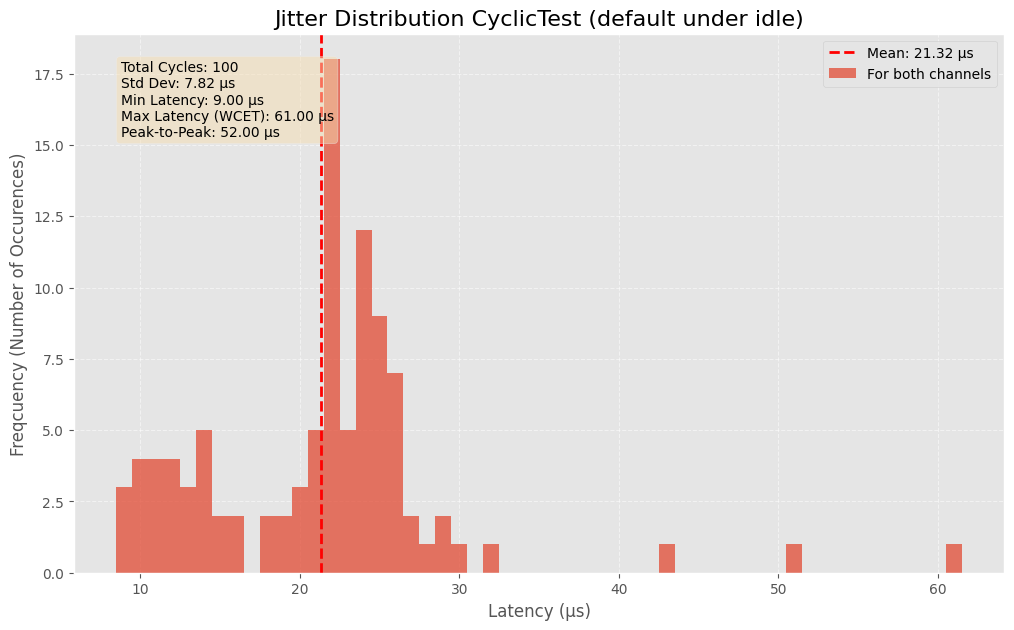

In [144]:
# Plot histogram idle
proc.plot_histograms(plots[0], show=True)

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-21-14-25-34/jitter_histogram_default_load-net_rise.png'


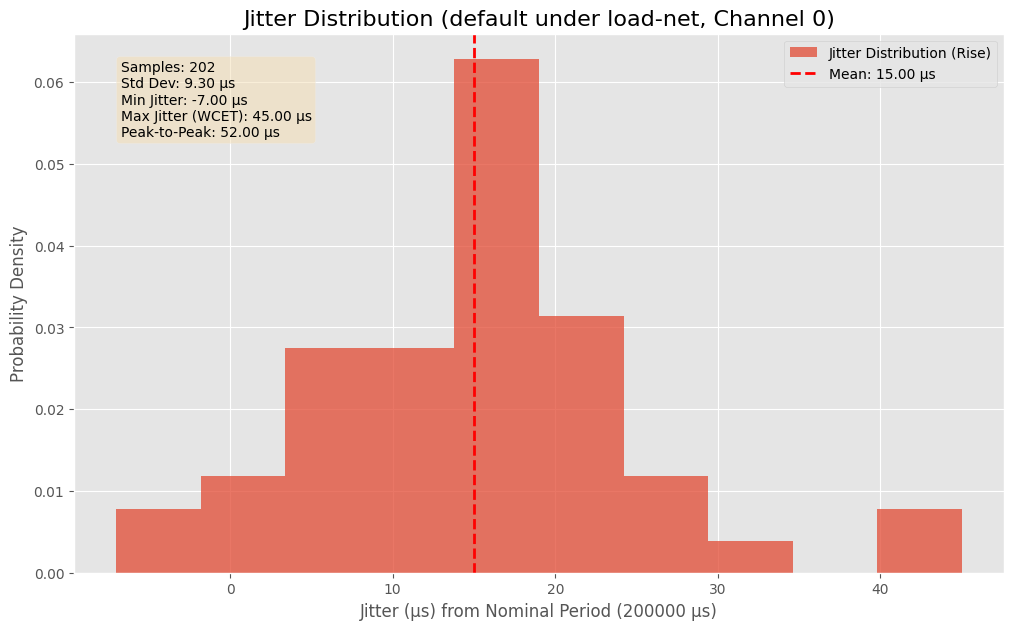

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-21-14-25-34/jitter_histogram_default_load-net_fall.png'


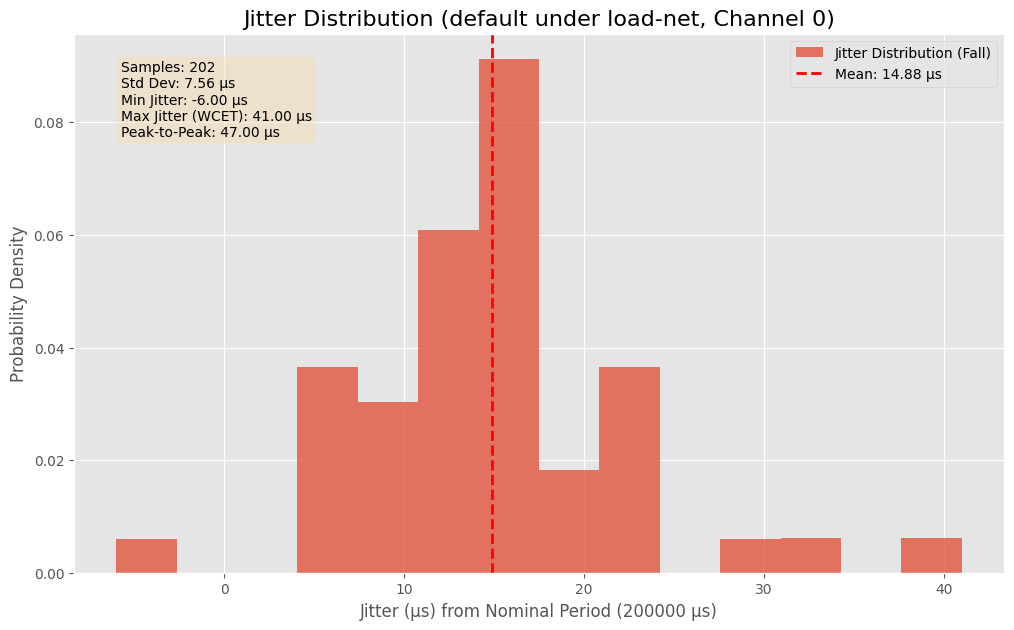

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-21-14-25-34/jitter_histogram_default_load-net_rise_fall.png'


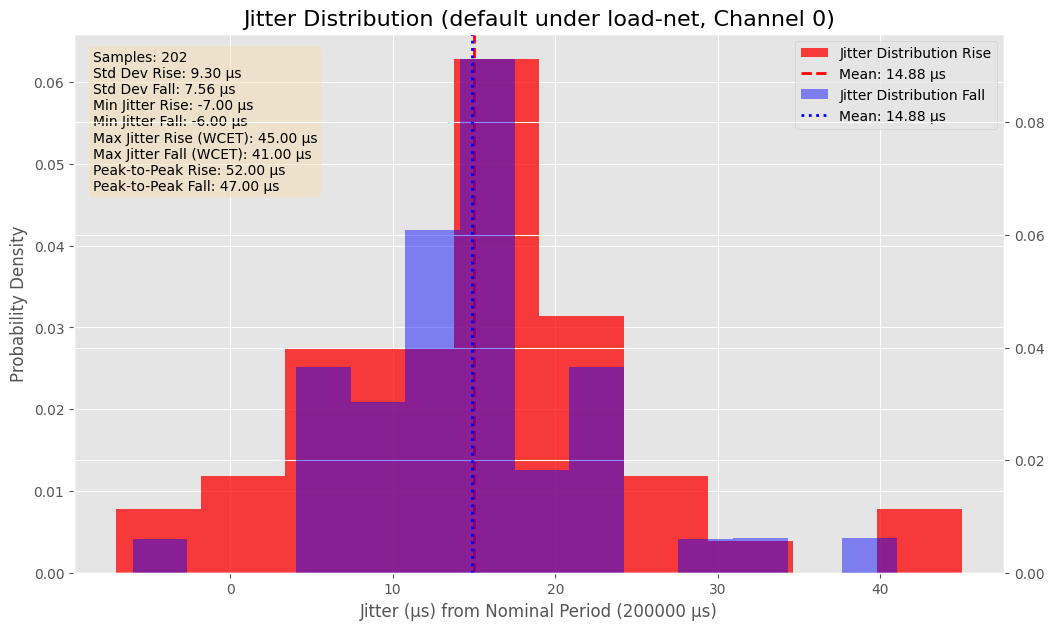

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-21-14-25-34/jitter_histogram_default_load-net_rise.png'


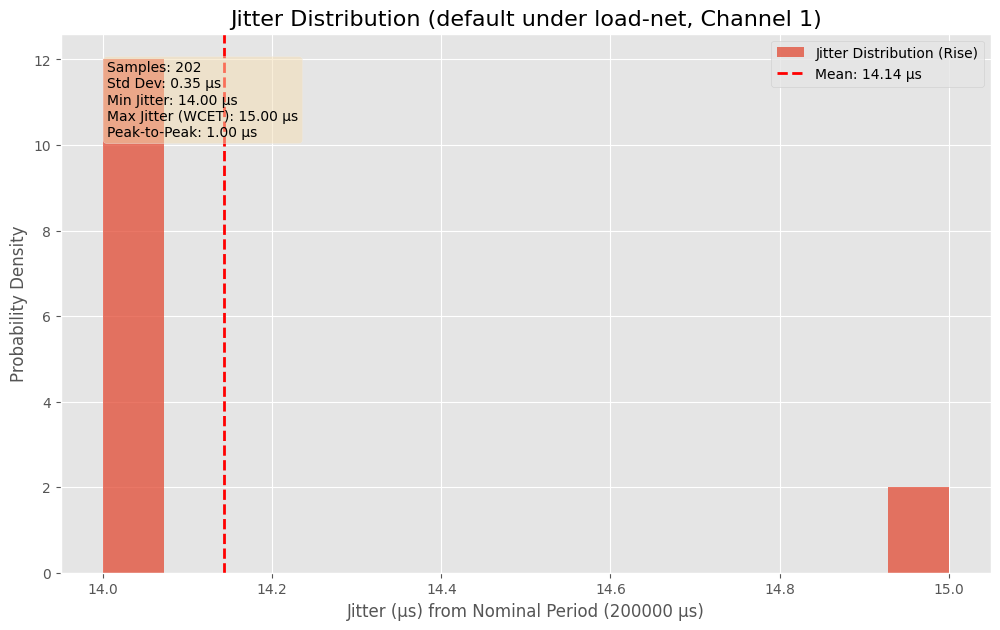

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-21-14-25-34/jitter_histogram_default_load-net_fall.png'


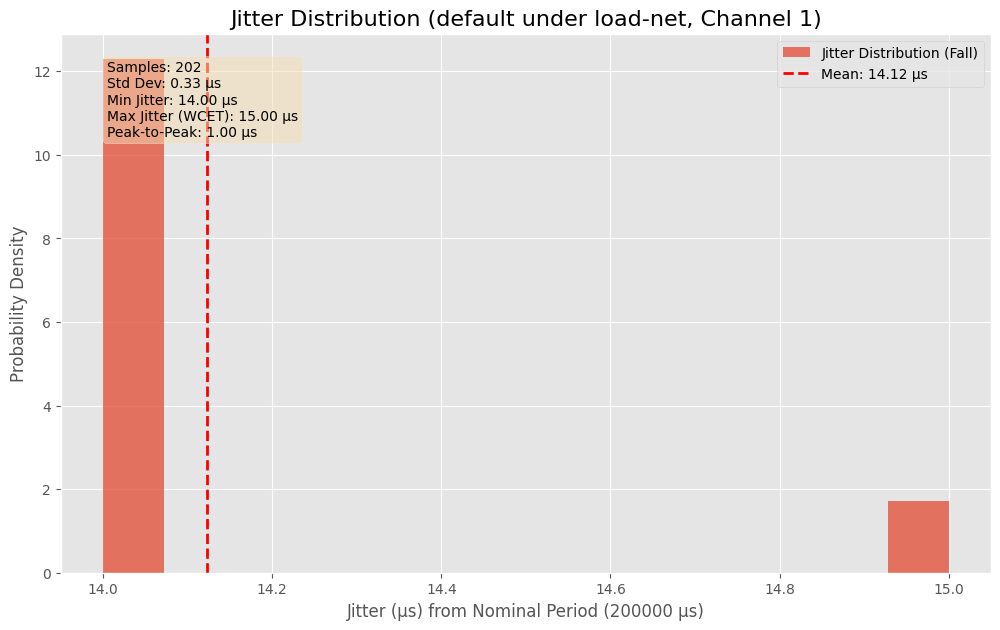

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-21-14-25-34/jitter_histogram_default_load-net_rise_fall.png'


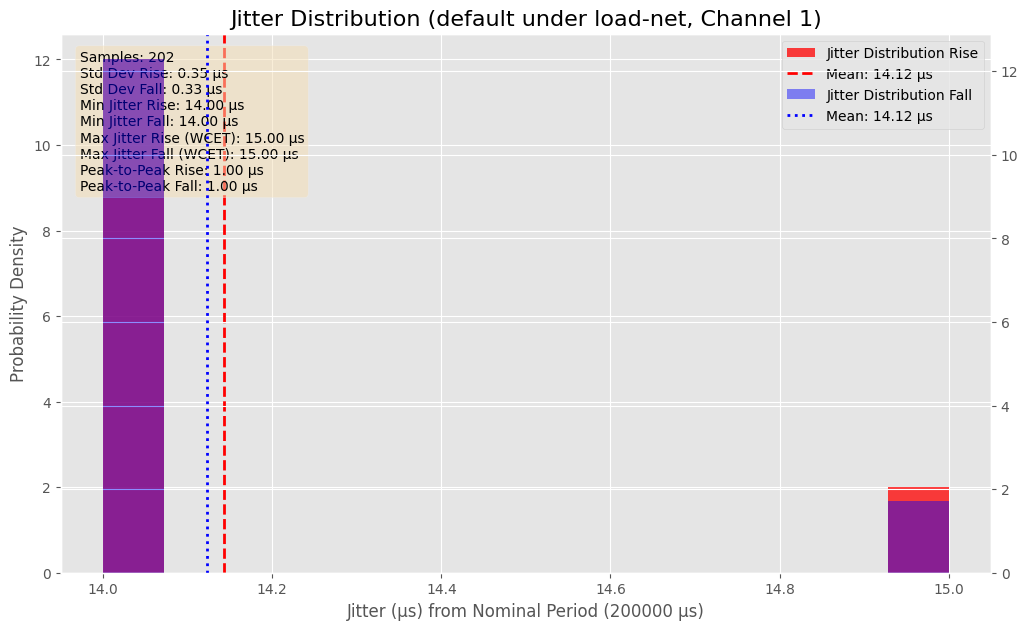

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-21-14-25-34/jitter_histogram_default_load-net_cyclic_test.png'


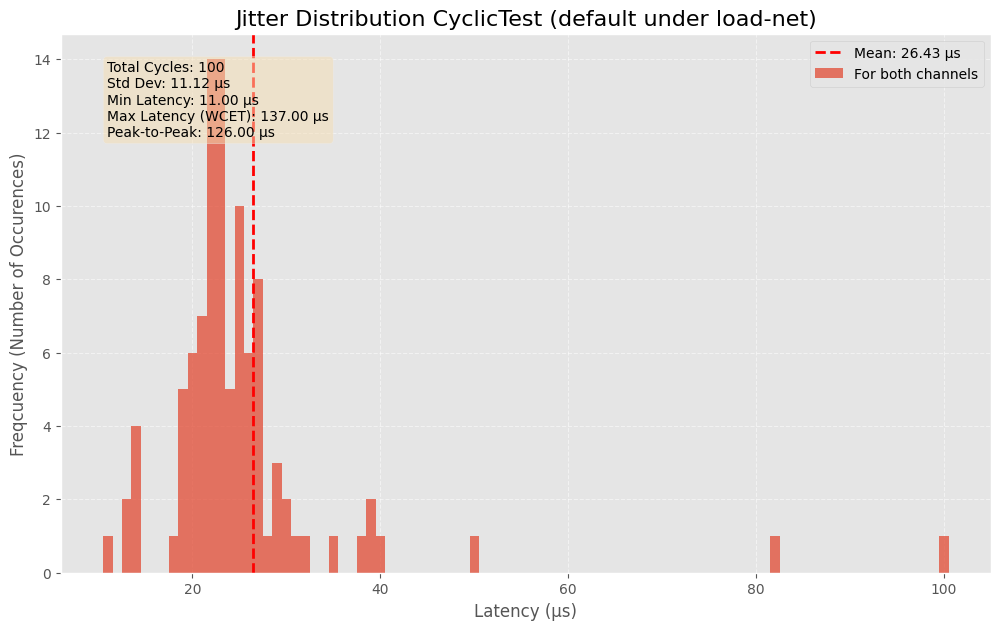

In [145]:
# Plot histogram load
proc.plot_histograms(plots[1], show=True)

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-21-14-25-34/jitter_phase_shift_default_idle.png'


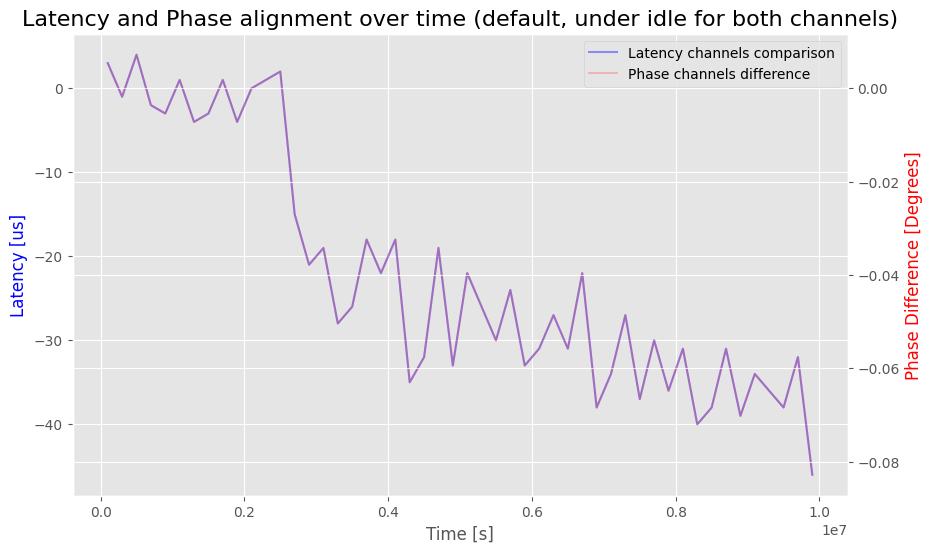

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-21-14-25-34/jitter_phase_shift_default_load-net.png'


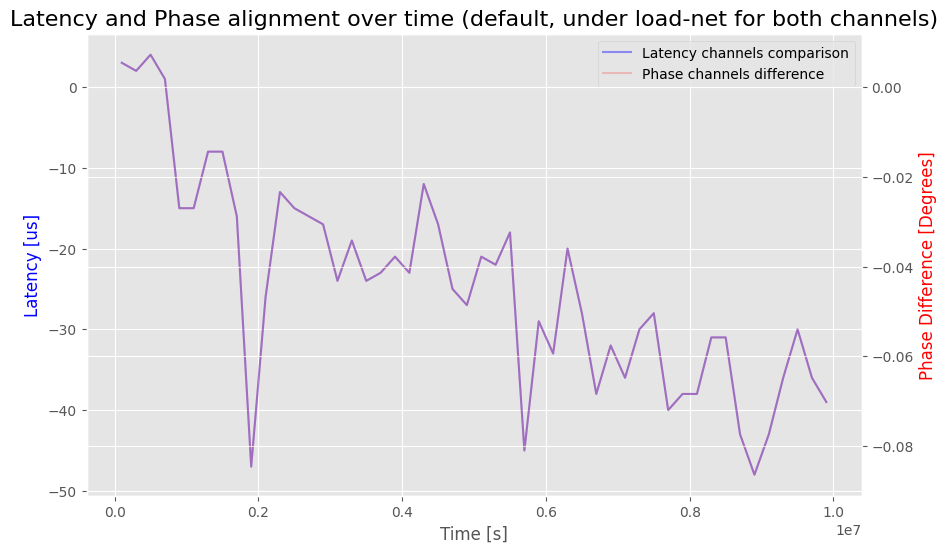

In [146]:
proc.plot_phase_shift_combined(plots[0], show=True)
proc.plot_phase_shift_combined(plots[1], show=True)

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-21-14-25-34/jitter_signal_drift_default_idle_rise_fall_0.png'


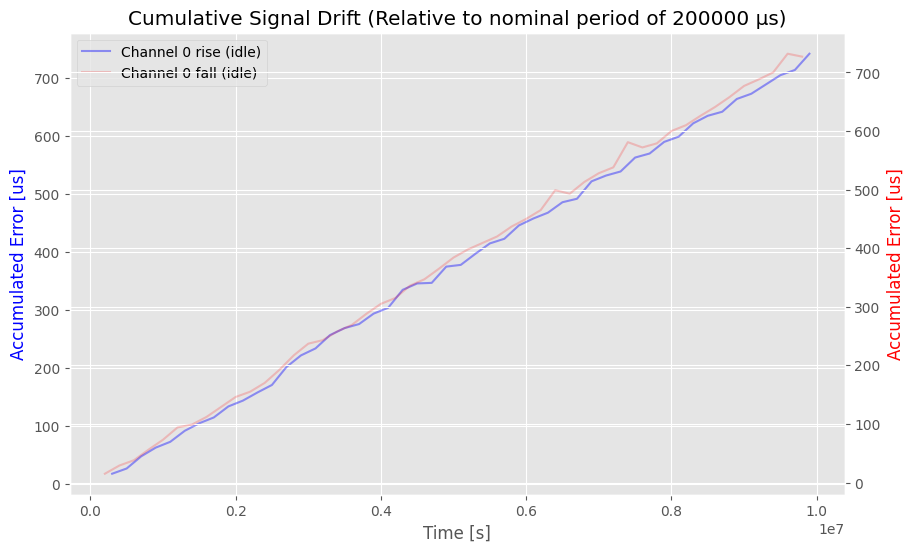

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-21-14-25-34/jitter_signal_drift_default_idle_rise_fall_1.png'


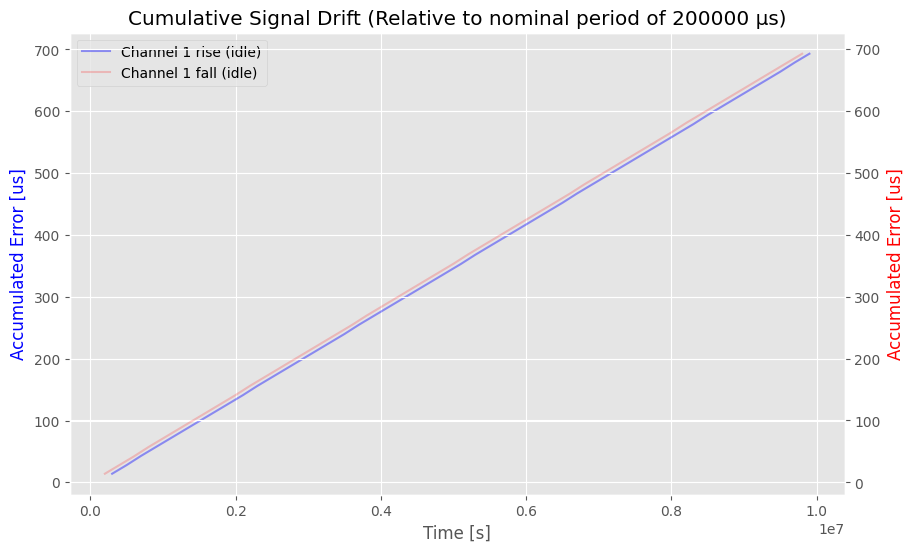

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-21-14-25-34/jitter_signal_drift_default_load-net_rise_fall_0.png'


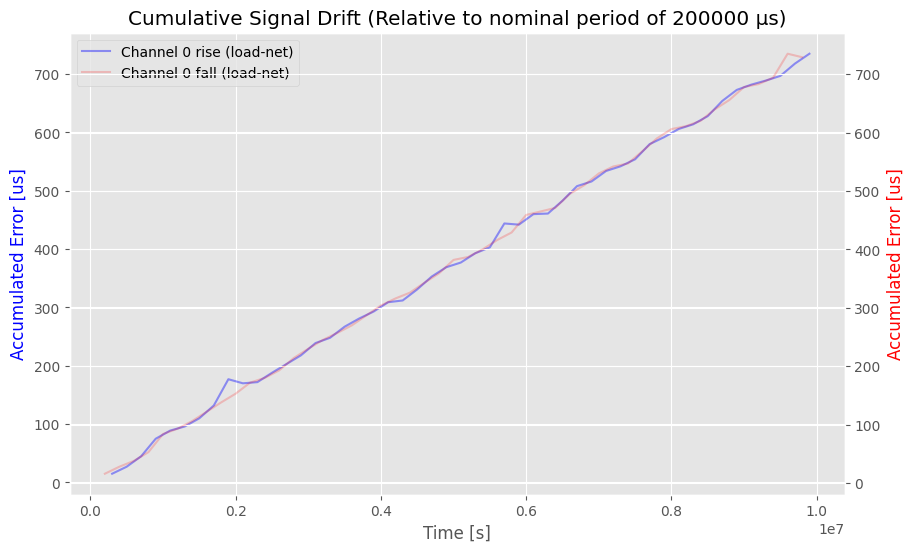

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-21-14-25-34/jitter_signal_drift_default_load-net_rise_fall_1.png'


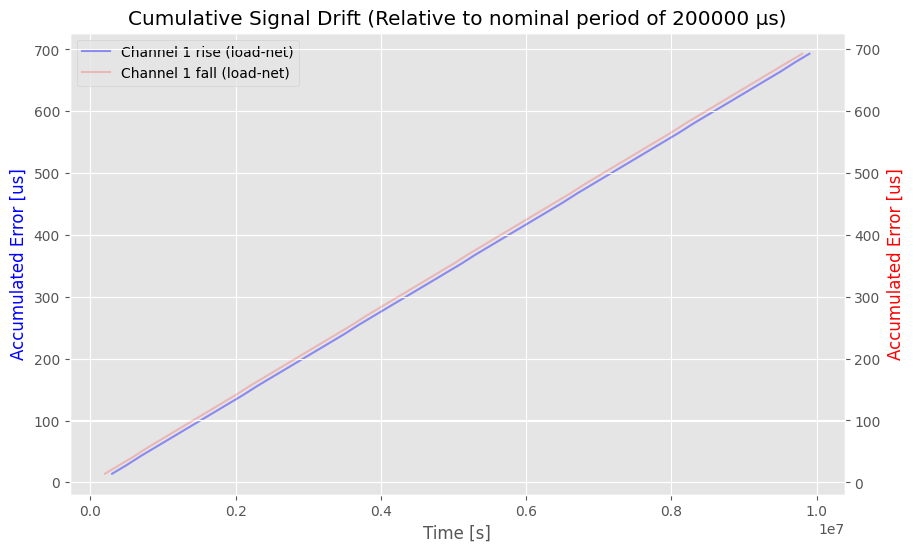

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-21-14-25-34/jitter_signal_drift_default_idle_0_1.png'


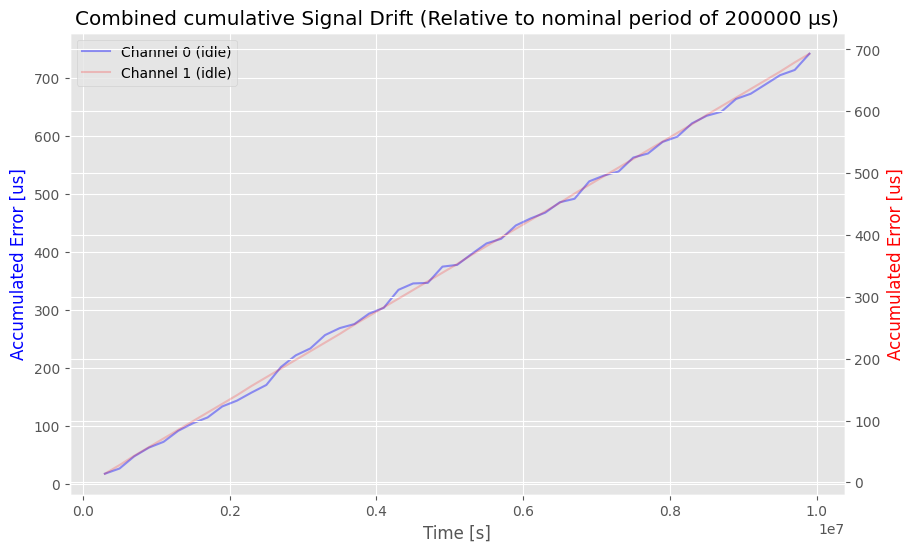

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-21-14-25-34/jitter_signal_drift_default_load-net_0_1.png'


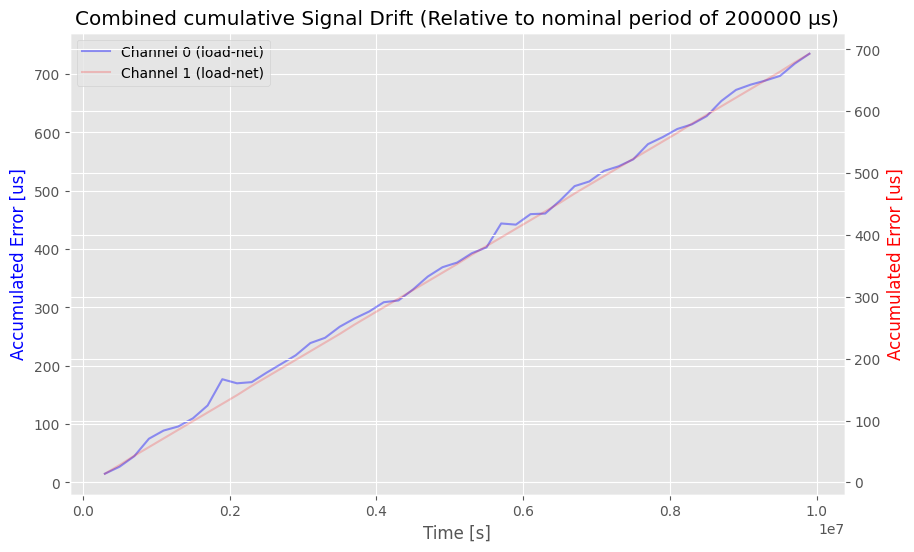

In [147]:
# Individual
proc.plot_signal_drift(plots[0], show=True)
proc.plot_signal_drift(plots[1], show=True)

# Combined
proc.plot_signal_drift_combined(plots[0], show=True)
proc.plot_signal_drift_combined(plots[1], show=True)

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-21-14-25-34/jitter_duty_cycle_default_idle_load-net_0.png'


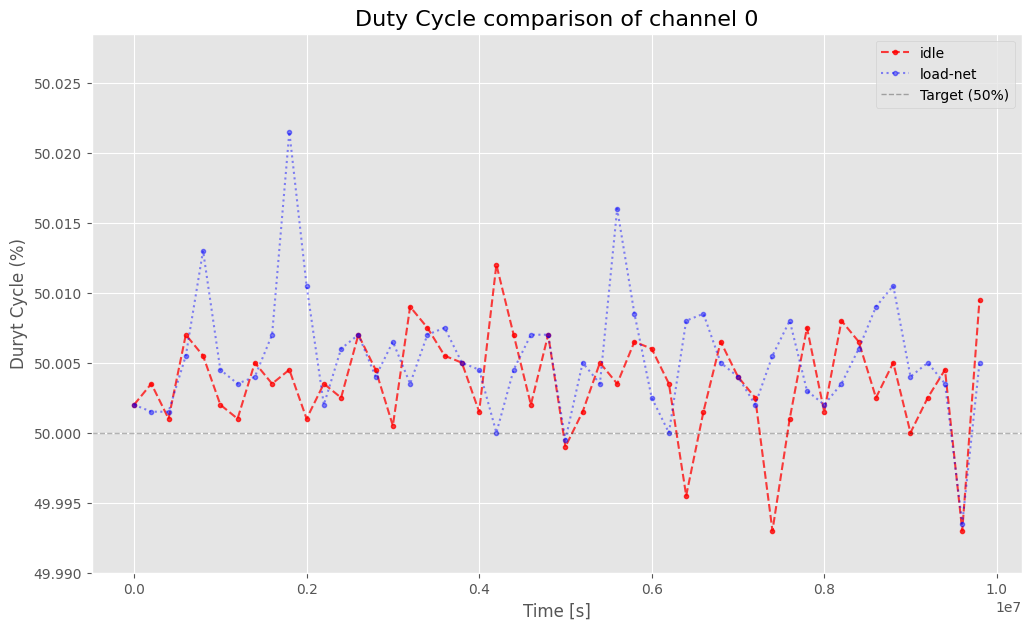

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local-rtk/test_results/default_2026-05-21-14-25-34/jitter_duty_cycle_default_idle_load-net_1.png'


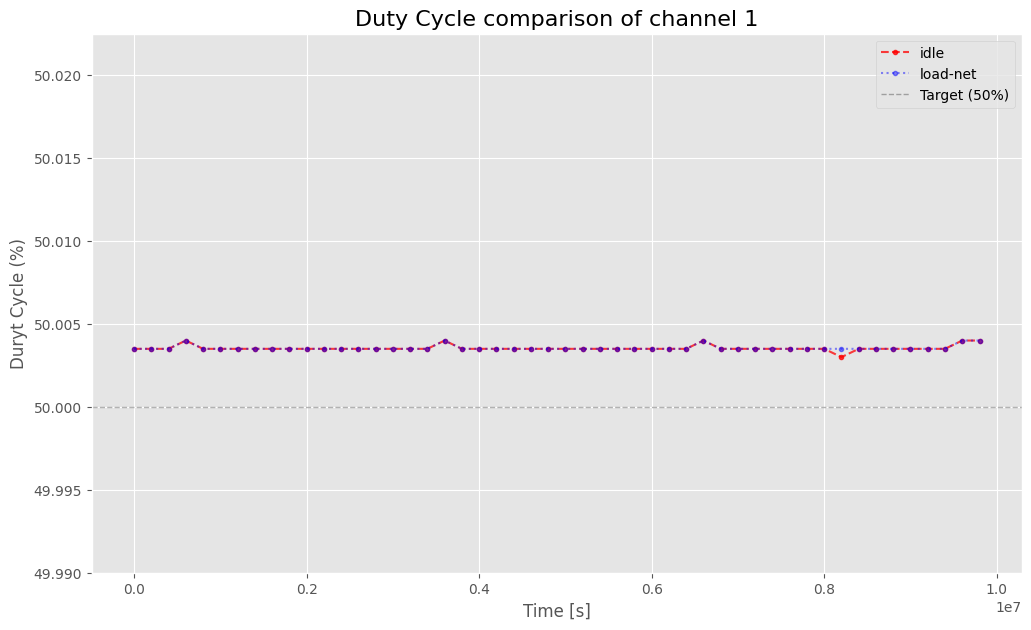

In [148]:
proc.plot_duty_cycle_combined(plots[0], plots[1], 0, show=True, y_lim=(49.99, 50.0285))
proc.plot_duty_cycle_combined(plots[0], plots[1], 1, show=True, y_lim=(49.99, 50.0225))